In [1]:
import pandas as pd
import numpy as np
import requests
import time
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt

In [2]:
ramen_data  = pd.read_csv('C:/Users/skapuganti1/Documents/Jupyter scripts/Python with SDC/datasets/ramen-ratings.csv')
ramen_data = ramen_data[['Review #', 'Brand', 'Variety', 'Style', 'Country', 'Stars']]
#ramen_list['search_param'] = ramen_list['Variety'].str.replace(' ', '+', regex = False)

ramen_data = ramen_data.rename(columns = {"Review #" : "Review" })
ramen_data

,Review,Brand,Variety,Style,Country,Stars
0,2580,New Touch,T's Restaurant Tantanmen,Cup,Japan,3.75
1,2579,Just Way,Noodles Spicy Hot Sesame Spicy Hot Sesame Guan...,Pack,Taiwan,1
2,2578,Nissin,Cup Noodles Chicken Vegetable,Cup,USA,2.25
3,2577,Wei Lih,GGE Ramen Snack Tomato Flavor,Pack,Taiwan,2.75
4,2576,Ching's Secret,Singapore Curry,Pack,India,3.75
...,...,...,...,...,...,...
2575,5,Vifon,"Hu Tiu Nam Vang [""Phnom Penh"" style] Asian Sty...",Bowl,Vietnam,3.5
2576,4,Wai Wai,Oriental Style Instant Noodles,Pack,Thailand,1
2577,3,Wai Wai,Tom Yum Shrimp,Pack,Thailand,2
2578,2,Wai Wai,Tom Yum Chili Flavor,Pack,Thailand,2


In [3]:
def diet(num_rev):
    link = None
    page_num = 1
    while link is None:
        if page_num == 1:
            url = f"https://www.theramenrater.com/?s={num_rev}"
        else: 
            url = f"https://www.theramenrater.com/page/{page_num}/?s={num_rev}"
    #url = f"https://www.theramenrater.com/?s={num_rev}"
        page = requests.get(url, timeout = 10)
        
        ssoup = BeautifulSoup(page.text, 'html')
        #print(soup.prettify())
        atag = ssoup.find_all('a', rel = 'bookmark')
        for a in atag:
            if f"#{num_rev}:" in a.text.strip() or f"#{num_rev} " in a.text.strip() or f"{num_rev}:" in a.text.strip():
                link = a.get('href')
                break
        page_num += 1
    #print(atag)
    #print(link)
    page = requests.get(link, timeout = 10)
    psoup = BeautifulSoup(page.text, 'html')
    ptag = psoup.find_all('p')
    for p in ptag:
        if "vegan" in p.text.lower() or "vegetarian" in p.text.lower() or "meat free" in p.text.lower():
            return("Veg")
            break
    else:
        return("Non-Veg")

In [4]:
for row in range(len(ramen_data)):
    ramen_data.at[row, 'Veg'] = diet(ramen_data.at[row,  'Review'])
    result = ramen_data.at[row, 'Veg']
    print("Completed row ",row, ramen_data.at[row, 'Review'], result)
    time.sleep(1)

Completed row  0 2580 Veg
Completed row  1 2579 Veg
Completed row  2 2578 Non-Veg
Completed row  3 2577 Veg
Completed row  4 2576 Veg
Completed row  5 2575 Veg
Completed row  6 2574 Non-Veg
Completed row  7 2573 Veg
Completed row  8 2572 Non-Veg
Completed row  9 2571 Veg
Completed row  10 2570 Non-Veg
Completed row  11 2569 Non-Veg
Completed row  12 2568 Non-Veg
Completed row  13 2567 Non-Veg
Completed row  14 2566 Non-Veg
Completed row  15 2565 Veg
Completed row  16 2564 Veg
Completed row  17 2563 Non-Veg
Completed row  18 2562 Veg
Completed row  19 2561 Non-Veg
Completed row  20 2560 Non-Veg
Completed row  21 2559 Non-Veg
Completed row  22 2558 Non-Veg
Completed row  23 2557 Non-Veg
Completed row  24 2556 Veg
Completed row  25 2555 Veg
Completed row  26 2554 Veg
Completed row  27 2553 Non-Veg
Completed row  28 2552 Non-Veg
Completed row  29 2551 Non-Veg
Completed row  30 2550 Non-Veg
Completed row  31 2549 Non-Veg
Completed row  32 2548 Veg
Completed row  33 2547 Veg
Completed row  3

In [5]:
ramen_list = ramen_data

In [6]:
#Average Rating, number of products by Country
ramen_list['Stars'] = pd.to_numeric(ramen_list['Stars'], errors = 'coerce')

avg_rating_country = ramen_list.groupby('Country').agg(
                            avg = ('Stars', 'mean'),
                            num = ('Review', 'count')).sort_values(by = 'avg', ascending = False).reset_index()
print(avg_rating_country)

          Country       avg  num
0          Brazil  4.350000    5
1         Sarawak  4.333333    3
2        Cambodia  4.200000    5
3        Malaysia  4.154194  156
4       Singapore  4.126147  109
5       Indonesia  4.067460  126
6           Japan  3.981605  352
7         Myanmar  3.946429   14
8            Fiji  3.875000    4
9       Hong Kong  3.801825  137
10    South Korea  3.790554  309
11  United States  3.750000    1
12         Mexico  3.730000   25
13     Bangladesh  3.714286    7
14         Taiwan  3.665402  224
15        Germany  3.638889   27
16         Poland  3.625000    4
17        Hungary  3.611111    9
18          Dubai  3.583333    3
19        Finland  3.583333    3
20        Holland  3.562500    4
21          Nepal  3.553571   14
22        Estonia  3.500000    2
23          Ghana  3.500000    2
24            USA  3.457043  323
25          China  3.421893  169
26          India  3.395161   31
27       Thailand  3.384817  191
28    Philippines  3.329787   47
29       C

In [7]:
#Average Rating, number of products by Veg/Non-Veg
avg_rating_veg = ramen_list.groupby('Veg').agg(
                            avg = ('Stars', 'mean'),
                            num = ('Review', 'count')).sort_values(by = 'avg', ascending = False).reset_index()
print(avg_rating_veg)

       Veg       avg   num
0  Non-Veg  3.779227  1443
1      Veg  3.496186  1137


In [8]:
#number of products by packaging
avg_rating_style = ramen_list.groupby('Style').agg(
                            avg = ('Stars', 'mean'),
                            num = ('Review', 'count')).sort_values(by = 'avg', ascending = False).reset_index()
print(avg_rating_style)

  Style       avg   num
0   Bar  5.000000     1
1   Box  4.291667     6
2  Pack  3.700458  1531
3  Bowl  3.670686   481
4  Tray  3.545139   108
5   Can  3.500000     1
6   Cup  3.498500   450


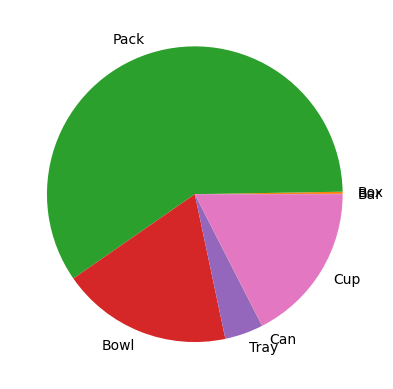

In [9]:
#pi chart for the packaging
plt.pie(avg_rating_style['num'], labels = avg_rating_style['Style'])
plt.show()

In [10]:
#number of products by brand
avg_rating_brand = ramen_list.groupby('Brand').agg(
                            avg = ('Stars', 'mean'),
                            num = ('Review', 'count')).sort_values(by = 'num', ascending = False).reset_index()
avg_rating_brand_filtered = avg_rating_brand[avg_rating_brand['num']>=5]
print(avg_rating_brand_filtered)

             Brand       avg  num
0           Nissin  3.918570  381
1         Nongshim  4.000000   98
2         Maruchan  3.554276   76
3             Mama  3.628873   71
4            Paldo  4.018939   66
..             ...       ...  ...
117    Sainsbury's  2.700000    5
118         Cintan  3.300000    5
119  Fashion Foods  1.800000    5
120        Chencun  3.400000    5
121          Azami  1.950000    5

[122 rows x 3 columns]


           Brand       avg  num
0         Nissin  3.918570  381
1       Nongshim  4.000000   98
2       Maruchan  3.554276   76
3           Mama  3.628873   71
4          Paldo  4.018939   66
5          Myojo  3.801587   63
6        Indomie  4.070755   53
7  Samyang Foods  4.068627   52
8         Ottogi  3.394444   46
9   Vina Acecook  3.536765   34


<function matplotlib.pyplot.show(close=None, block=None)>

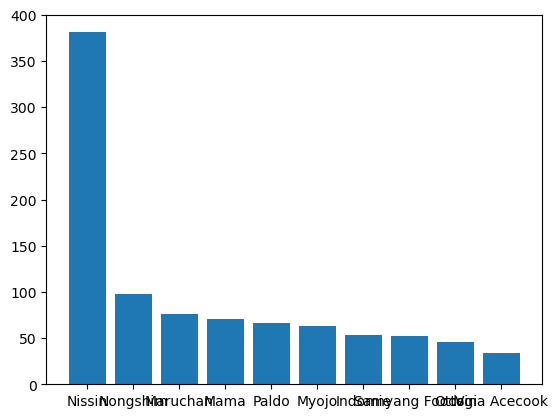

In [11]:
#Plot
avg_rating_brand_chart = avg_rating_brand_filtered.head(10)
print(avg_rating_brand_chart)

plt.bar(avg_rating_brand_chart['Brand'], avg_rating_brand_chart['num'])
plt.show

In [12]:
# Which brand should I try from the RamenRater? I am a vegetarian
avg_rating_trial = ramen_list.groupby(['Brand', 'Veg']).agg(
                            avg = ('Stars', 'mean'),
                            num = ('Review', 'count')).sort_values(by = 'num', ascending = False).reset_index()
#avg_rating_trial_filtered = avg_rating_trial[avg_rating_trial['Veg'] == 'Veg' & avg_rating_trial['num'] >1].sort_values(by = 'avg', ascending = False)
avg_rating_trial_filtered = avg_rating_trial.query('Veg == "Veg" and num>1')
avg_rating_trial_filtered

,Brand,Veg,avg,num
1,Nissin,Veg,3.587838,74
7,Nongshim,Veg,3.795455,33
8,Mama,Veg,3.398387,31
10,Paldo,Veg,3.888393,28
11,Indomie,Veg,4.083333,27
...,...,...,...,...
303,Tiger Tiger,Veg,2.375000,2
305,Knorr,Veg,2.000000,2
307,Just Way,Veg,2.750000,2
308,Trident,Veg,3.125000,2
